In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("fake_job_postings.csv")

In [3]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [4]:
df.shape

(17880, 18)

In [5]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [7]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [8]:
df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
df['fraudulent'].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

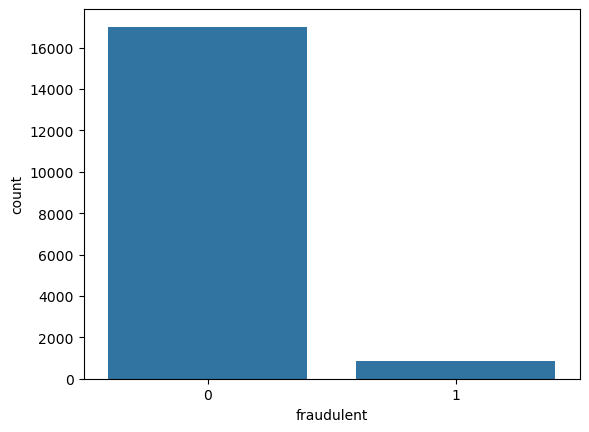

In [10]:
sns.countplot(x="fraudulent", data=df)
plt.show()

In [11]:
(df.isnull().sum() / len(df)) * 100

job_id                  0.000000
title                   0.000000
location                1.935123
department             64.580537
salary_range           83.959732
company_profile        18.501119
description             0.005593
requirements           15.078300
benefits               40.335570
telecommuting           0.000000
has_company_logo        0.000000
has_questions           0.000000
employment_type        19.412752
required_experience    39.429530
required_education     45.329978
industry               27.421700
function               36.101790
fraudulent              0.000000
dtype: float64

In [12]:
df = df.drop(['job_id'], axis=1)

In [13]:
df.columns

Index(['title', 'location', 'department', 'salary_range', 'company_profile',
       'description', 'requirements', 'benefits', 'telecommuting',
       'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [14]:
df['text'] = df['title'].fillna('') + " " + \
             df['company_profile'].fillna('') + " " + \
             df['description'].fillna('') + " " + \
             df['requirements'].fillna('') + " " + \
             df['benefits'].fillna('')

In [15]:
df = df[['text','fraudulent']]

In [16]:
df.head()

,text,fraudulent
0,"Marketing Intern We're Food52, and we've creat...",0
1,Customer Service - Cloud Video Production 90 S...,0
2,Commissioning Machinery Assistant (CMA) Valor ...,0
3,Account Executive - Washington DC Our passion ...,0
4,Bill Review Manager SpotSource Solutions LLC i...,0


In [17]:
df.isnull().sum()

text          0
fraudulent    0
dtype: int64

In [18]:
df.shape

(17880, 2)

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['text'])

y = df['fraudulent']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [21]:
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (14304, 5000)
Testing data shape: (3576, 5000)


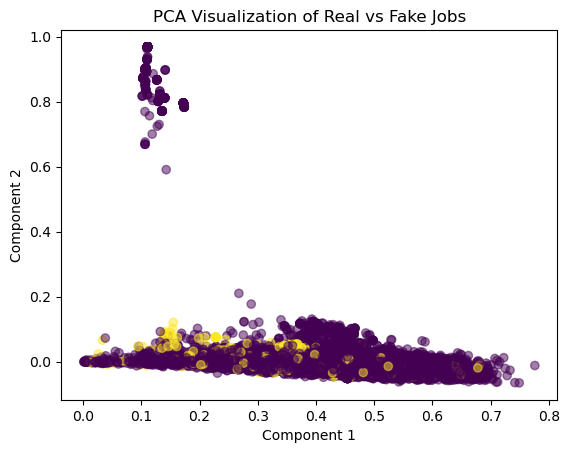

[0.02037062 0.03998925]


In [22]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2)

X_pca = svd.fit_transform(X_train)

# plot
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, alpha=0.5)
plt.title("PCA Visualization of Real vs Fake Jobs")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()


print(svd.explained_variance_ratio_)

In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9711968680089486

In [27]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)



array([[3395,    0],
       [ 103,   78]])

In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
rf_pred = rf.predict(X_test)

In [31]:
accuracy_score(y_test, rf_pred)

0.9801454138702461

In [32]:
confusion_matrix(y_test, rf_pred)

array([[3395,    0],
       [  71,  110]])

In [33]:
from sklearn.metrics import classification_report

In [34]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3395
           1       1.00      0.61      0.76       181

    accuracy                           0.98      3576
   macro avg       0.99      0.80      0.87      3576
weighted avg       0.98      0.98      0.98      3576



In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# define model
rf = RandomForestClassifier(random_state=42)

# parameters to test
param = {
    "n_estimators": [50, 100]
}

# grid search
grid = GridSearchCV(rf, param, cv=3)

# train
grid.fit(X_train, y_train)

# best model
best_rf = grid.best_estimator_

# predict
pred = best_rf.predict(X_test)

# results
print("Best parameter:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, pred))

Best parameter: {'n_estimators': 50}
Accuracy: 0.979586129753915


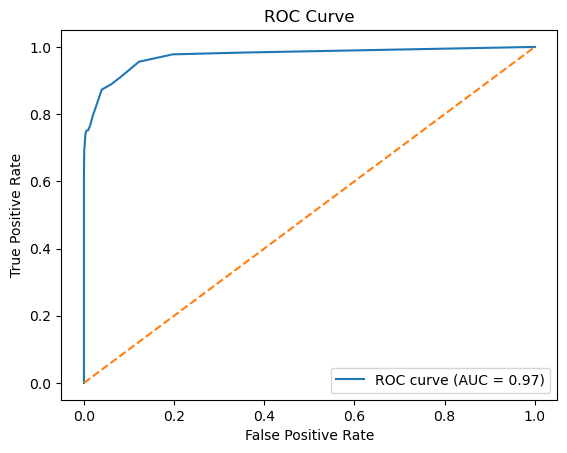

ROC-AUC score: 0.9736075964816637


In [97]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# get prediction probabilities
y_prob = best_rf.predict_proba(X_test)[:,1]

# calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# calculate AUC score
roc_auc = auc(fpr, tpr)

# plot graph
plt.figure()
plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC score:", roc_auc)

In [36]:

best_rf = grid.best_estimator_

# predict on test data
pred = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.979586129753915


In [37]:
from sklearn.svm import LinearSVC

In [38]:
svm = LinearSVC()

svm.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [39]:
svm_pred = svm.predict(X_test)

In [40]:
accuracy_score(y_test, svm_pred)

0.9854586129753915

In [41]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3395
           1       0.98      0.73      0.84       181

    accuracy                           0.99      3576
   macro avg       0.98      0.86      0.91      3576
weighted avg       0.99      0.99      0.98      3576



In [42]:
log_acc = accuracy_score(y_test, y_pred)
rf_acc = accuracy_score(y_test, rf_pred)
svm_acc = accuracy_score(y_test, svm_pred)

print("Logistic Regression:", log_acc)
print("Random Forest:", rf_acc)
print("SVM:", svm_acc)

Logistic Regression: 0.9711968680089486
Random Forest: 0.9801454138702461
SVM: 0.9854586129753915


In [43]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM"],
    "Accuracy": [log_acc, rf_acc, svm_acc]
})

results

,Model,Accuracy
0,Logistic Regression,0.971197
1,Random Forest,0.980145
2,SVM,0.985459


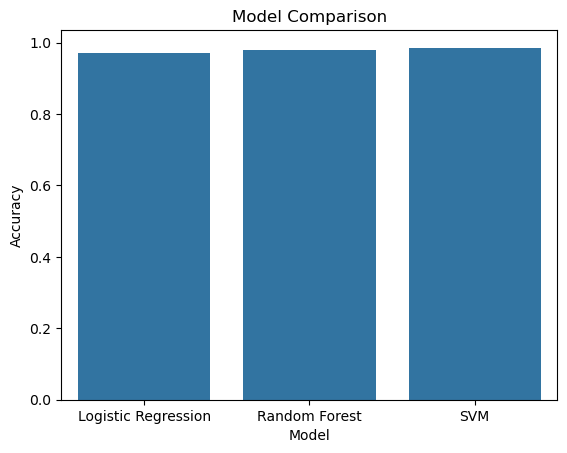

In [44]:
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Model Comparison")
plt.show()

In [45]:
results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,SVM,0.985459
1,Random Forest,0.980145
0,Logistic Regression,0.971197


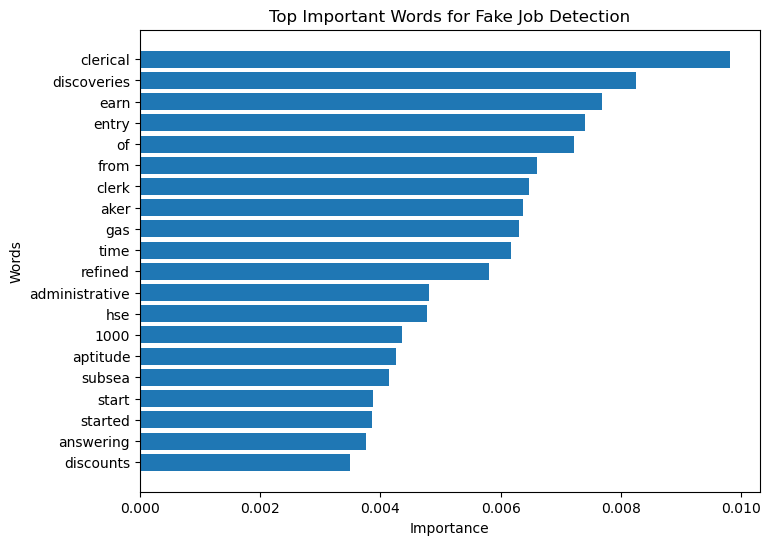

In [49]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = tfidf.get_feature_names_out()

# use tuned model
importances = best_rf.feature_importances_

indices = np.argsort(importances)[-20:]

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), feature_names[indices])
plt.title("Top Important Words for Fake Job Detection")
plt.xlabel("Importance")
plt.ylabel("Words")
plt.show()

In [51]:
sample = ["Work from home and earn money fast. No experience needed."]

sample_vec = tfidf.transform(sample)

best_rf.predict(sample_vec)

array([1])

In [52]:
sample = ["10 years of experience required , the applicants with that experience can apply"]

sample_vec = tfidf.transform(sample)

best_rf.predict(sample_vec)

array([0])

In [ ]:
df.to_csv("cleaned_fake_jobs.csv", index=False)